In [1]:
from __future__ import division
import matplotlib as lib
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
import numpy as np
import pylab
import pandas as pd
import os
import pickle
%matplotlib inline

In [2]:
generation_list = []

for i in range(2002):
    generation_list.append(i)
    
print(len(generation_list))

2002


In [3]:
def get_data1(file_list):
    
    total_fit_mean = []
    total_fit_std = []
    
    for i in file_list:
        f = pd.read_csv(i,dtype=str)
    
        fit_mean = []
        fit_std = []
    
       
        fit_mean.extend(list(pd.Series(f.OptFitness_Mean,dtype=float)))
        fit_std.extend(list(pd.Series(f.OptFitness_Std,dtype=float)))
    
    
        total_fit_mean.append(fit_mean)
        total_fit_std.append(fit_std)
    
        
    return total_fit_mean, total_fit_std

### 1. Move along all dimensions deterministically

In [4]:
os.chdir(r"D:\Prof. Azevedo\Simulation of Ciliate Evolution\20190223_Test of FGM_Movement of Optimum\Data\1.1. Along All Dimensions")

In [5]:
all_dim = ['NoPley_Move_STD_001.csv']

In [6]:
ad = get_data1(all_dim)

ad_fit_mean =ad[0]
ad_fit_std = ad[1]

### 2. Move along one dimension deterministically

In [7]:
os.chdir(r"D:\Prof. Azevedo\Simulation of Ciliate Evolution\20190223_Test of FGM_Movement of Optimum\Data\1.2. Along One Dimension")

In [8]:
one_dim = ['NoPley_OneDim_Move_STD005.csv']

In [9]:
od = get_data1(one_dim)

od_fit_mean =od[0]
od_fit_std = od[1]

### 3. Move along the diagonal of the optimum deterministically

In [10]:
os.chdir(r"D:\Prof. Azevedo\Simulation of Ciliate Evolution\20190223_Test of FGM_Movement of Optimum\Data\1.3. StraightLine Move")

In [11]:
dg_line = ['StraightLine_Move_STD_Rate0003.csv']

In [12]:
dl = get_data1(dg_line)

dl_fit_mean =dl[0]
dl_fit_std = dl[1]

In [13]:
def publication_figure(axis):
    plt.rcParams.update({'font.size': 36})
    ax = axis
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    ax.spines['left'].set_linewidth(8)
    ax.spines['bottom'].set_linewidth(8)
    ax.spines['left'].set_position(('outward', 10))
    ax.spines['bottom'].set_position(('outward', 10))
    #ax.xaxis.set_ticks([])
    ax.tick_params(axis='x', which='both', bottom='on', top='off',labelbottom='on', size=20, width=10, direction='out', pad=50, colors='black')
    ax.tick_params(axis='y', which='both', left='on', right='off',labelbottom='on', size=20, width=10, direction='out', pad=50, colors='black')

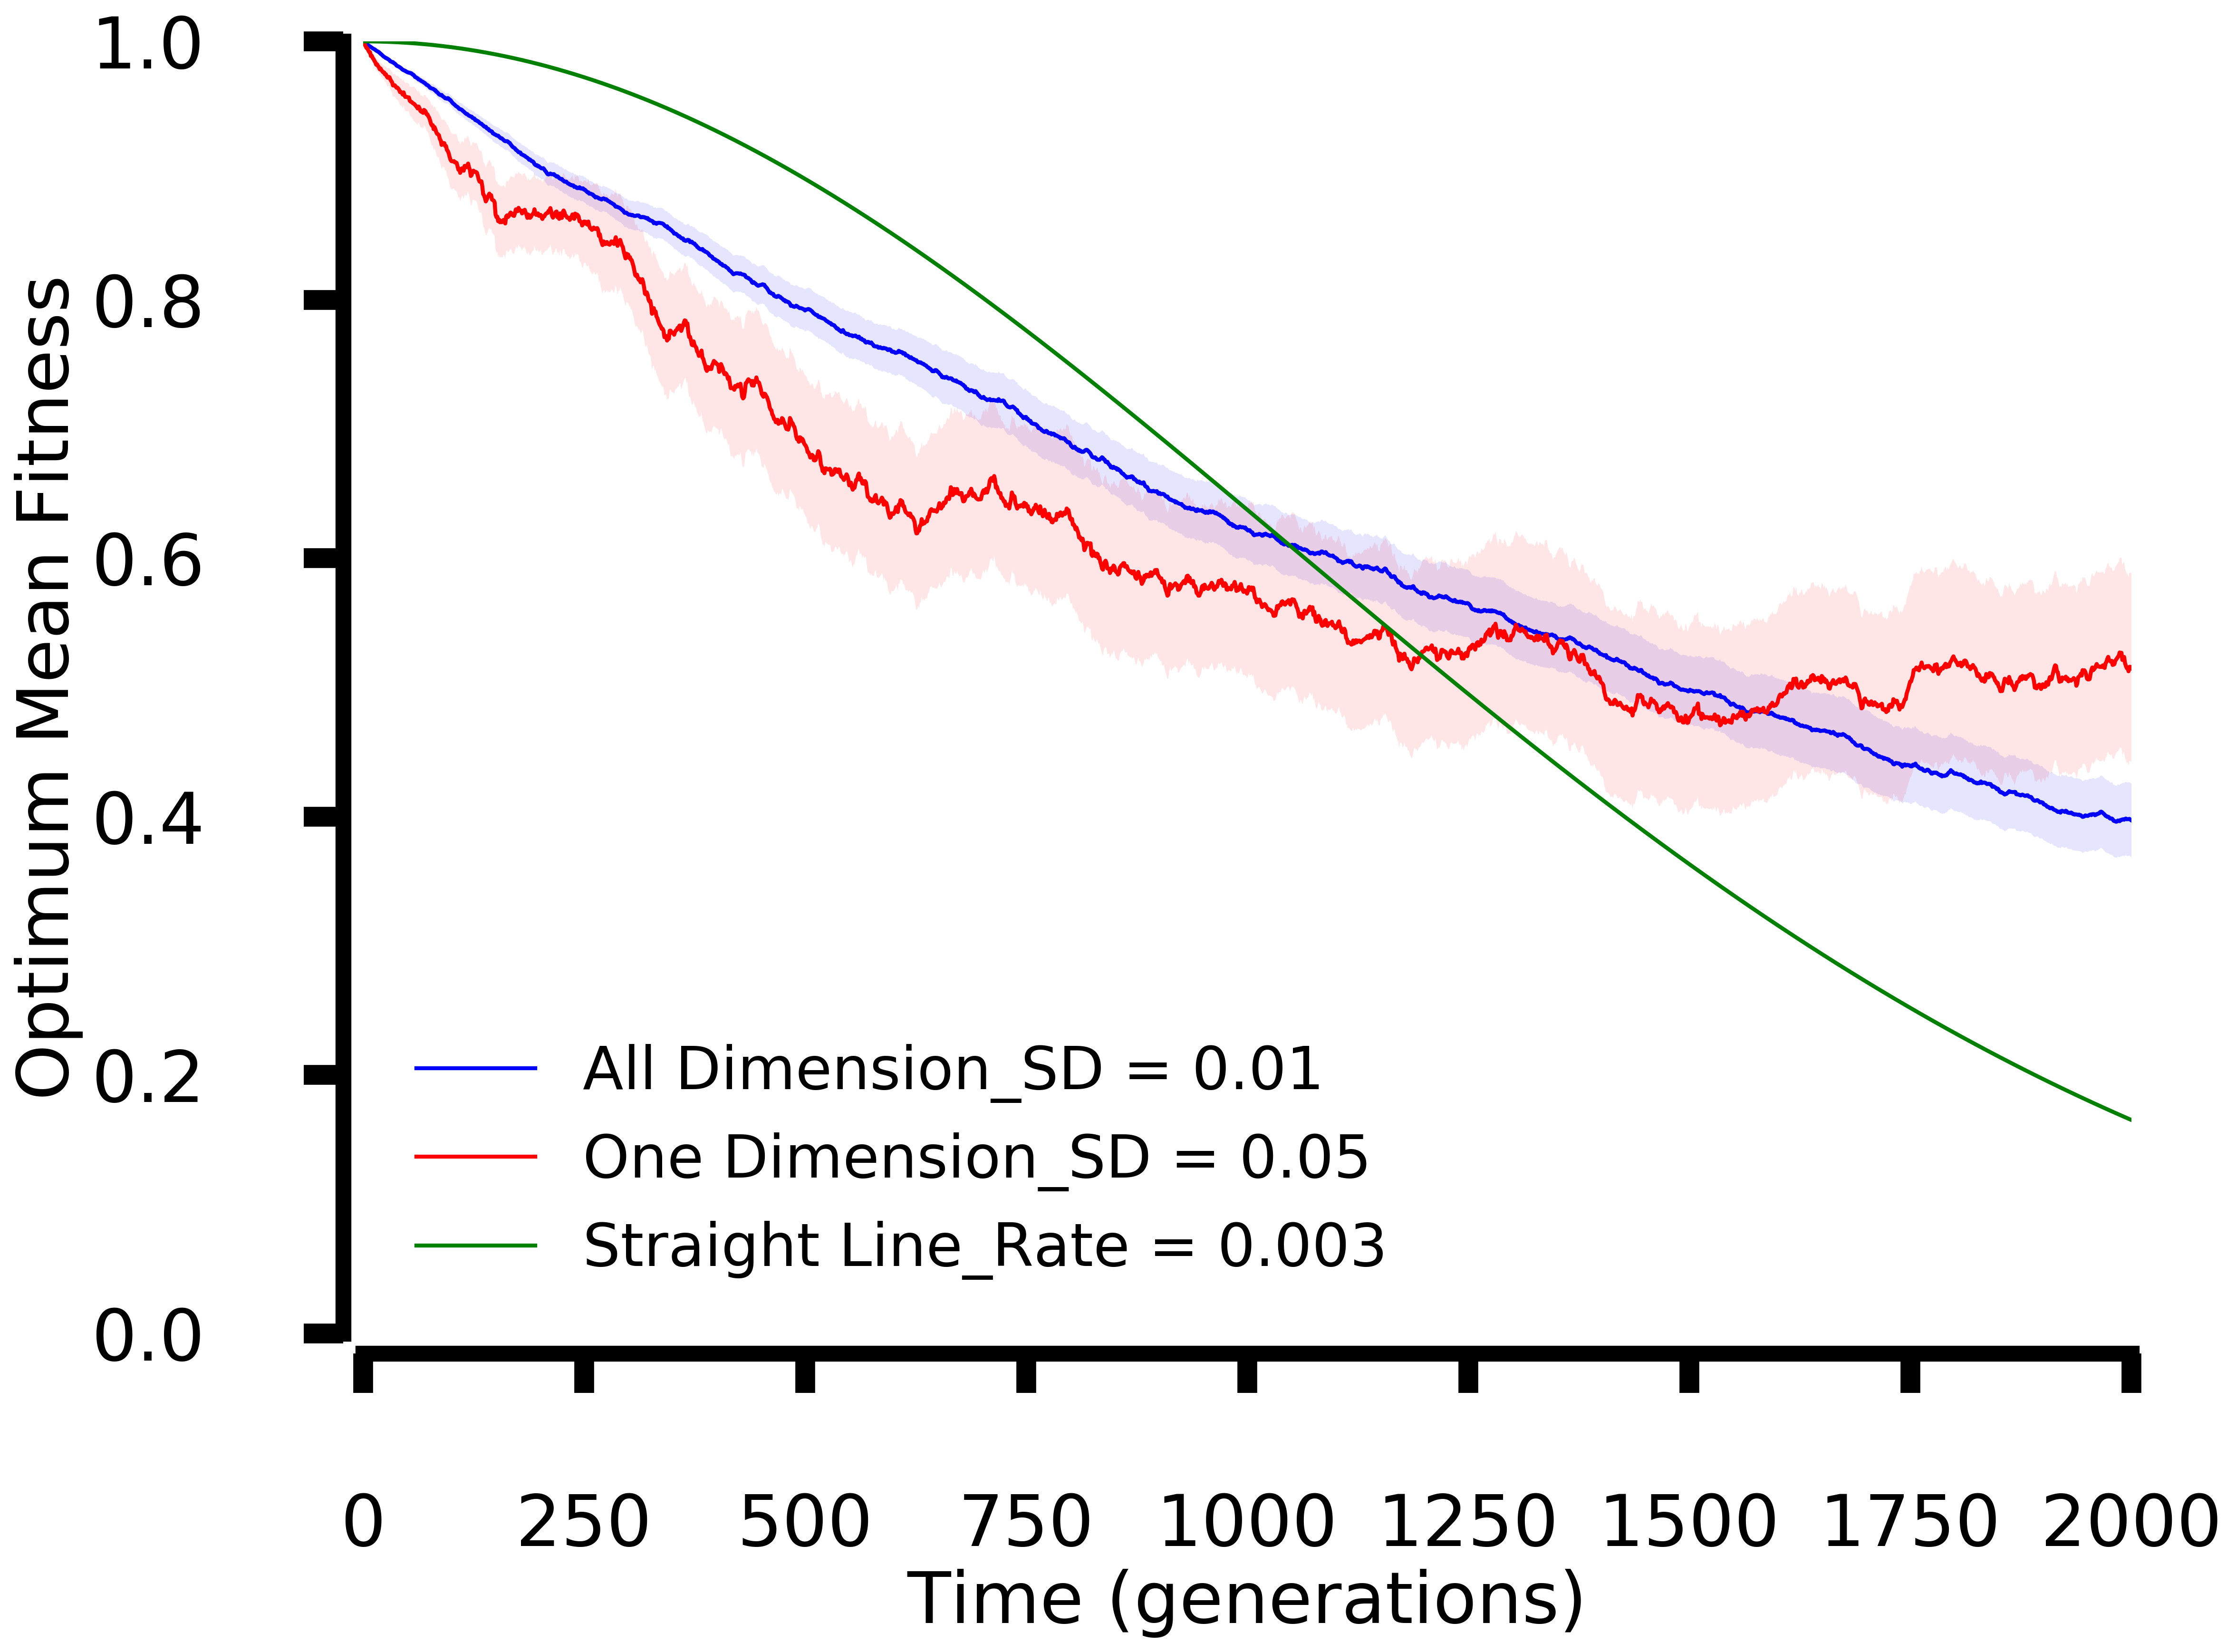

In [17]:
fig = plt.figure(figsize=(16, 12), dpi =300)
ax = fig.add_subplot(111)
publication_figure(ax)
# ax.scatter(0,0)

ax.set_xlim(0,2000)

t = generation_list

a1 = ad_fit_mean[0]
error_a1 = list(1.98* np.array(ad_fit_std[0])/((100)**0.5))

a2 = od_fit_mean[0]
error_a2 = list(1.98* np.array(od_fit_std[0])/((100)**0.5))

a3 = dl_fit_mean[0]
error_a3 = list(1.98* np.array(dl_fit_std[0])/((100)**0.5))


ax.set_xlabel('Time (generations)', fontsize =36)
ax.set_ylabel('Optimum Mean Fitness', fontsize =36)


ax.plot(t,a1,'b', label = 'All Dimension_SD = 0.01',  linewidth=2.0, alpha =1)
ax.fill_between(t, np.array(a1)- np.array(error_a1), np.array(a1)+ np.array(error_a1), alpha =0.1, facecolor='b')

ax.plot(t,a2,'r', label = 'One Dimension_SD = 0.05',  linewidth=2.0, alpha =1)
ax.fill_between(t, np.array(a2)- np.array(error_a2), np.array(a2)+ np.array(error_a2), alpha =0.1, facecolor='r')

ax.plot(t,a3,'g', label = 'Straight Line_Rate = 0.003',  linewidth=2.0, alpha =1)
ax.fill_between(t, np.array(a3)- np.array(error_a3), np.array(a3)+ np.array(error_a3), alpha =0.1, facecolor='g')


# plt.axhline(y=0.5, linewidth=2.0, color ='k',ls ='dashed')

ax.minorticks_off()
# ax.yaxis.set_ticks(np.arange(start, end, 0.1))

# legend = ax.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0., fontsize =25)
# frame = legend.get_frame()
# # frame.set_framecolor('black')
# frame.set_edgecolor('black')

# extraticks=[0.45]
# ax.set_yticks(list(ax.get_yticks()) + extraticks)

ax.set_ylim(0, 1)


plt.legend(loc='lower left', frameon=False, prop={'size':30})